# E06 Matrix Sensing Noise Robustness

### Problem

This notebook studies noisy Matrix Sensing and separates fitting observations from recovering the target matrix. The data model is

$$y_i=\langle A_i,X^\star\rangle+\xi_i,\qquad \xi_i=\sigma\eta_i,\qquad \eta_i\overset{\mathrm{i.i.d.}}{\sim}\mathcal{N}(0,1),$$

and the noisy training objective is

$$f_\sigma(X)=\frac{1}{2m}\sum_{i=1}^{m}(\langle A_i,X\rangle-y_i)^2.$$

The target distribution is $X^\star=U\operatorname{diag}(s)V^\top$ with Gaussian QR singular vectors, fixed rank $r=5$, and spectrum cases `hard-k1`, `exp-k10`, and `exp-k100`. Measurements are Gaussian and

$$m=\alpha dr,\qquad \alpha\in\{2,4,8\}.$$

The noise scale varies over

$$\sigma\in\{0,10^{-4},10^{-3},10^{-2},3\cdot10^{-2},10^{-1}\}.$$

The direct matrix initialization is $X_0=10^{-2}G_0$ with i.i.d. Gaussian entries. The notebook records training loss, recovery error

$$e(\widehat X)=\frac{\lVert\widehat X-X^\star\rVert_F}{\lVert X^\star\rVert_F},$$

and a fresh noiseless measurement loss on newly sampled Gaussian matrices.

The experiment fixes dimension, rank, measurement law, and initialization; it varies noise scale $\sigma$, sample-complexity factor $\alpha$, spectrum/conditioning, optimizer, and seed. Its purpose is to test whether low noisy training loss remains informative about $X^\star$ as noise and conditioning change.

When reading the results, focus first on recovery error versus noise, then compare noisy training loss with fresh noiseless measurement loss. Large gaps mean the optimizer fits the observed data without accurately recovering $X^\star$. Per-step work scales as $\Theta(md^2)=\Theta(\alpha rd^3)$, and the full grid can execute up to $27000000$ optimization steps.

## Implementation Details: Skip Unless Modifying The Experiment

The code below is visible for reproducibility. A reader can skip it unless changing the grid, optimizer definitions, stopping rule, diagnostics, or plotting calls.

In [1]:
import math
import os
import pathlib
import sys
import time
for name in ["OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"]:
    os.environ.setdefault(name, "1")

import IPython.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT = pathlib.Path.cwd().resolve()
if not (PROJECT / "problems").exists():
    PROJECT = PROJECT.parent.resolve()
sys.path.insert(0, str(PROJECT))

import optimizers
import plotting
import problems.MatrixConstruction
import problems.MatrixSensing
import util
import util.diagnostics

torch.set_default_dtype(torch.float64)
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

print(f"project = {PROJECT}")
print(f"torch   = {torch.__version__}")


project = /Users/tianyangliu/Desktop/muonexperiment
torch   = 2.11.0


/opt/anaconda3/envs/muonexperiment-torch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Parameters And Runs


In [2]:
NOTEBOOK_ID = "E06 noise robustness"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE_NAME = "float64"
ALGOS = ["Muon", "Muon-Exact", "Shampoo", "Adam", "SGD"]
SEEDS = list(range(50))
SMOKE_TEST = False
SMOKE_TEST_MAX_STEPS = 10
FULL_ITERS = 2000

BASE_SPEC = dict(
    problem="MatrixSensing",
    d=60,
    rank=5,
    lr=0.01,
    dist="normal",
    init_scale=0.01,
    iters=SMOKE_TEST_MAX_STEPS if SMOKE_TEST else FULL_ITERS,
    early_stop=True,
    early_stop_min_steps=20,
    early_stop_patience=20,
    early_stop_min_delta=1e-3,
    device_type=DEVICE.type,
    dtype_name=DTYPE_NAME,
)
SPECTRUM_CASES = [
    dict(spectrum_case="hard-k1", spectrum="hard-cutoff", kappa=1.0),
    dict(spectrum_case="exp-k10", spectrum="exponential-decay", kappa=10.0),
    dict(spectrum_case="exp-k100", spectrum="exponential-decay", kappa=100.0),
]
NOISE_LEVELS = [0.0, 1e-4, 1e-3, 1e-2, 3e-2, 1e-1]
M_MULTIPLIERS = [2, 4, 8]
NUM_WORKERS = min(8, os.cpu_count() or 1)
JOBLIB_BACKEND = "loky"

runs = pd.DataFrame([
    {**BASE_SPEC, **case, "m_multiplier": m_multiplier, "noise": noise, "algo": algo, "seed": seed}
    for case in SPECTRUM_CASES
    for m_multiplier in M_MULTIPLIERS
    for noise in NOISE_LEVELS
    for algo in ALGOS
    for seed in SEEDS
])
runs.insert(0, "run_id", range(len(runs)))

print(f"device={DEVICE}, workers={NUM_WORKERS}, backend={JOBLIB_BACKEND}")
print(f"smoke_test={SMOKE_TEST}, steps_per_run={BASE_SPEC['iters']}")
print(f"runs={len(runs)}, max_total_steps={len(runs) * BASE_SPEC['iters']}")
IPython.display.display(runs)


device=cpu, workers=8, backend=loky
smoke_test=False, steps_per_run=2000
runs=1350, max_total_steps=2700000


,run_id,problem,d,rank,lr,dist,init_scale,iters,early_stop,early_stop_min_steps,...,early_stop_min_delta,device_type,dtype_name,spectrum_case,spectrum,kappa,m_multiplier,noise,algo,seed
0,0,MatrixSensing,60,5,0.01,normal,0.01,2000,True,20,...,0.001,cpu,float64,hard-k1,hard-cutoff,1.0,2,0.0,Muon,0
1,1,MatrixSensing,60,5,0.01,normal,0.01,2000,True,20,...,0.001,cpu,float64,hard-k1,hard-cutoff,1.0,2,0.0,Muon,1
2,2,MatrixSensing,60,5,0.01,normal,0.01,2000,True,20,...,0.001,cpu,float64,hard-k1,hard-cutoff,1.0,2,0.0,Muon,2
3,3,MatrixSensing,60,5,0.01,normal,0.01,2000,True,20,...,0.001,cpu,float64,hard-k1,hard-cutoff,1.0,2,0.0,Muon,3
4,4,MatrixSensing,60,5,0.01,normal,0.01,2000,True,20,...,0.001,cpu,float64,hard-k1,hard-cutoff,1.0,2,0.0,Muon,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1345,1345,MatrixSensing,60,5,0.01,normal,0.01,2000,True,20,...,0.001,cpu,float64,exp-k100,exponential-decay,100.0,8,0.1,SGD,0
1346,1346,MatrixSensing,60,5,0.01,normal,0.01,2000,True,20,...,0.001,cpu,float64,exp-k100,exponential-decay,100.0,8,0.1,SGD,1
1347,1347,MatrixSensing,60,5,0.01,normal,0.01,2000,True,20,...,0.001,cpu,float64,exp-k100,exponential-decay,100.0,8,0.1,SGD,2
1348,1348,MatrixSensing,60,5,0.01,normal,0.01,2000,True,20,...,0.001,cpu,float64,exp-k100,exponential-decay,100.0,8,0.1,SGD,3


### Pseudocode

```text
for each spectrum, measurement multiplier, noise level, optimizer, seed:
    build noisy observations y from X_star
    initialize X
    define step(state): training loss -> backward -> optimizer.step -> recovery error
    repeat step until max iterations, divergence, or patience early stopping
    at the final iterate, evaluate a fresh noiseless measurement error
compare training loss against true recovery error
```


### Worker Definition


In [3]:
def dtype_from_name(dtype_name):
    dtype = getattr(torch, dtype_name)
    if not isinstance(dtype, torch.dtype):
        raise ValueError(f"unknown torch dtype: {dtype_name}")
    return dtype


def configure_torch(dtype):
    torch.set_default_dtype(dtype)
    torch.set_num_threads(1)
    try:
        torch.set_num_interop_threads(1)
    except RuntimeError:
        pass


def make_optimizer(algo, params, lr, rank):
    if algo == "Muon" and hasattr(torch.optim, "Muon"):
        try:
            return torch.optim.Muon(params, lr=lr, weight_decay=0.0, momentum=0.9, nesterov=False, ns_steps=5)
        except TypeError:
            pass
    if algo == "Muon":
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="newton_schulz", ns_steps=5)
    if algo in {"Muon-Exact", "MuonExact"}:
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="exact")
    if algo == "Muon-NS-1":
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="newton_schulz", ns_steps=1)
    if algo == "Muon-NS-10":
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="newton_schulz", ns_steps=10)
    if algo == "Muon-Truncated":
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="truncated", rank=rank)
    if algo == "Muon-RandSVD":
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="randsvd", rank=rank, oversample=5, power_iters=1)
    if algo == "Shampoo":
        return optimizers.Shampoo(params, lr=lr, beta2=0.9, epsilon=1e-8)
    if algo == "Adam":
        return torch.optim.Adam(params, lr=lr)
    if algo == "SGD":
        return torch.optim.SGD(params, lr=lr, momentum=0.9)
    if algo == "NormalizedSGD":
        return optimizers.NormalizedSGD(params, lr=lr, momentum=0.9, norm_type="fro")
    if algo == "SpectralNormSGD":
        return optimizers.NormalizedSGD(params, lr=lr, momentum=0.9, norm_type="spectral")
    if algo == "LayerwiseNormalizedSGD":
        return optimizers.NormalizedSGD(params, lr=lr, momentum=0.9, norm_type="fro")
    raise ValueError(f"unknown algo: {algo}")


def show_figure(fig):
    IPython.display.display(fig)
    plt.close(fig)


def single_run(run):
    run = dict(run)
    d = int(run["d"])
    rank = int(run["rank"])
    seed = int(run["seed"])
    iters = int(run["iters"])
    early_stop = bool(run["early_stop"])
    early_stop_min_steps = int(run["early_stop_min_steps"])
    early_stop_patience = int(run["early_stop_patience"])
    early_stop_min_delta = float(run["early_stop_min_delta"])
    device = torch.device(run["device_type"])
    dtype = dtype_from_name(run["dtype_name"])
    configure_torch(dtype)

    problem = problems.MatrixSensing.make_matrix_sensing_problem(
        d,
        rank,
        noise=float(run["noise"]),
        dist=run["dist"],
        spectrum=run["spectrum"],
        kappa=float(run["kappa"]),
        seed=seed,
        device=device,
        dtype=dtype,
        m_multiplier=float(run.get("m_multiplier", 2.0)),
    )
    x = torch.nn.Parameter(
        problems.MatrixConstruction.randn((d, d), seed + 3000, device, dtype) * float(run["init_scale"])
    )
    optimizer = make_optimizer(run["algo"], [x], float(run["lr"]), rank)
    initial_loss = float(problem.loss(x).detach().cpu())
    best_loss = None
    early_stop_wait = 0
    rows = []
    start_time = time.perf_counter()

    def step():
        optimizer.zero_grad(set_to_none=True)
        loss = problem.loss(x)
        loss.backward()
        grad_norm = float(x.grad.detach().norm().cpu())
        optimizer.step()
        return float(loss.detach().cpu()), grad_norm

    for _ in range(iters):
        loss_value, grad_norm = step()
        if best_loss is None:
            best_loss = loss_value
        elif best_loss - loss_value >= early_stop_min_delta:
            best_loss = loss_value
            early_stop_wait = 0
        else:
            early_stop_wait += 1

        stop_reason = ""
        if not math.isfinite(loss_value) or loss_value > max(1e6, 1e6 * max(initial_loss, 1e-12)):
            stop_reason = "diverged"
        elif early_stop and len(rows) + 1 >= early_stop_min_steps and early_stop_wait >= early_stop_patience:
            stop_reason = "early_stop_patience"

        rows.append({
            **run,
            "m_meas": problem.m_meas,
            "initial_loss": initial_loss,
            "step": len(rows) + 1,
            "loss": loss_value,
            "grad_norm": grad_norm,
            "relative_matrix_error": util.diagnostics.relative_matrix_error(x.detach(), problem.target),
            "best_loss": best_loss,
            "early_stop_wait": early_stop_wait,
            "elapsed_s": time.perf_counter() - start_time,
            "stop_reason": stop_reason,
        })
        if stop_reason:
            break

    if rows and not rows[-1]["stop_reason"]:
        rows[-1]["stop_reason"] = "max_iters"

    if rows:
        fresh = problems.MatrixSensing.generate_measurements(
            d,
            problem.m_meas,
            run["dist"],
            seed + 9000,
            device,
            dtype,
        )
        clean_observations = torch.einsum("mij,ij->m", fresh, problem.target)
        fresh_pred = torch.einsum("mij,ij->m", fresh, x.detach())
        rows[-1]["fresh_noiseless_mse"] = float((0.5 * torch.mean((fresh_pred - clean_observations).square())).cpu())
    return pd.DataFrame(rows)


## Results

The execute cell materializes the long per-step `runs` table. The saved outputs below are the experimental results to inspect.

In [4]:
runs = util.run_experiments(
    runs,
    single_run,
    num_workers=NUM_WORKERS,
    backend=JOBLIB_BACKEND,
    algo_order=ALGOS,
    sort_columns=("run_id", "step"),
    desc=NOTEBOOK_ID,
)
IPython.display.display(runs)


E06 noise robustness:   0%|          | 0/1350 [00:00<?, ?run/s]

E06 noise robustness:   0%|          | 1/1350 [00:02<1:03:30,  2.82s/run]

E06 noise robustness:   0%|          | 2/1350 [00:03<29:03,  1.29s/run]  

E06 noise robustness:   0%|          | 5/1350 [00:03<09:02,  2.48run/s]

E06 noise robustness:   1%|          | 9/1350 [00:03<04:13,  5.28run/s]

...

E06 noise robustness: 100%|█████████▉| 1346/1350 [02:36<00:00,  4.45run/s]

E06 noise robustness: 100%|█████████▉| 1348/1350 [02:36<00:00,  6.17run/s]

E06 noise robustness: 100%|██████████| 1350/1350 [02:36<00:00,  8.09run/s]

E06 noise robustness: 100%|██████████| 1350/1350 [02:36<00:00,  8.60run/s]

,run_id,problem,d,rank,lr,dist,init_scale,iters,early_stop,early_stop_min_steps,...,initial_loss,step,loss,grad_norm,relative_matrix_error,best_loss,early_stop_wait,elapsed_s,stop_reason,fresh_noiseless_mse
0,0,MatrixSensing,60,5,0.01,normal,0.01,2000,True,20,...,2.529593,1,2.529593,5.856059,1.025853,2.529593,0,0.022744,,NaN
1,0,MatrixSensing,60,5,0.01,normal,0.01,2000,True,20,...,2.529593,2,2.228805,5.447971,1.021082,2.228805,0,0.025797,,NaN
2,0,MatrixSensing,60,5,0.01,normal,0.01,2000,True,20,...,2.529593,3,1.951595,5.047164,1.017156,1.951595,0,0.028051,,NaN
3,0,MatrixSensing,60,5,0.01,normal,0.01,2000,True,20,...,2.529593,4,1.697053,4.654006,1.014030,1.697053,0,0.029706,,NaN
4,0,MatrixSensing,60,5,0.01,normal,0.01,2000,True,20,...,2.529593,5,1.464368,4.269127,1.011681,1.464368,0,0.034707,,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111637,1349,MatrixSensing,60,5,0.01,normal,0.01,2000,True,20,...,1.178723,106,0.000812,0.014686,0.653175,0.001263,16,0.889136,,NaN
111638,1349,MatrixSensing,60,5,0.01,normal,0.01,2000,True,20,...,1.178723,107,0.000792,0.014337,0.653062,0.001263,17,0.891637,,NaN
111639,1349,MatrixSensing,60,5,0.01,normal,0.01,2000,True,20,...,1.178723,108,0.000772,0.014016,0.652952,0.001263,18,0.894398,,NaN
111640,1349,MatrixSensing,60,5,0.01,normal,0.01,2000,True,20,...,1.178723,109,0.000753,0.013722,0.652845,0.001263,19,0.896904,,NaN


### Result Tables


In [5]:
ordered_runs = runs.sort_values(["run_id", "step"])
dynamic_columns = [
    "step", "initial_loss", "loss", "grad_norm", "relative_matrix_error", "best_loss",
    "early_stop_wait", "elapsed_s", "stop_reason", "fresh_noiseless_mse",
]
run_summary = ordered_runs.groupby("run_id", as_index=False).first().drop(columns=dynamic_columns, errors="ignore")
run_summary = run_summary.merge(
    ordered_runs.groupby("run_id", as_index=False).agg(
        initial_loss=("initial_loss", "first"),
        final_loss=("loss", "last"),
        min_loss=("loss", "min"),
        relative_matrix_error=("relative_matrix_error", "last"),
        min_relative_matrix_error=("relative_matrix_error", "min"),
        actual_steps=("step", "last"),
        time_s=("elapsed_s", "last"),
        stop_reason=("stop_reason", "last"),
    ),
    on="run_id",
)
run_summary["time_per_step"] = run_summary["time_s"] / run_summary["actual_steps"].clip(lower=1)
run_summary["stopped_early"] = run_summary["stop_reason"].eq("early_stop_patience")
run_summary["diverged"] = run_summary["stop_reason"].eq("diverged")
run_summary["algo"] = pd.Categorical(run_summary["algo"], categories=ALGOS, ordered=True)
run_summary = run_summary.sort_values(["algo", "run_id"]).reset_index(drop=True)
run_summary["algo"] = run_summary["algo"].astype(str)
fresh_summary = ordered_runs.groupby("run_id", as_index=False).agg(fresh_noiseless_mse=("fresh_noiseless_mse", "last"))
run_summary = run_summary.merge(fresh_summary, on="run_id", how="left")
run_summary["recovery_loss_gap"] = np.log10(run_summary["relative_matrix_error"].clip(lower=1e-300)) - np.log10(run_summary["final_loss"].clip(lower=1e-300))
IPython.display.display(run_summary)


,run_id,problem,d,rank,lr,dist,init_scale,iters,early_stop,early_stop_min_steps,...,relative_matrix_error,min_relative_matrix_error,actual_steps,time_s,stop_reason,time_per_step,stopped_early,diverged,fresh_noiseless_mse,recovery_loss_gap
0,0,MatrixSensing,60,5,0.01,normal,0.01,2000,True,20,...,1.052777,1.009215,113,0.359876,early_stop_patience,0.003185,True,False,2.504567,2.216078
1,1,MatrixSensing,60,5,0.01,normal,0.01,2000,True,20,...,1.045432,1.008834,114,0.439414,early_stop_patience,0.003855,True,False,2.579059,2.220056
2,2,MatrixSensing,60,5,0.01,normal,0.01,2000,True,20,...,1.046053,1.012070,104,0.399514,early_stop_patience,0.003841,True,False,2.875730,2.122511
3,3,MatrixSensing,60,5,0.01,normal,0.01,2000,True,20,...,1.042528,1.013245,98,0.414854,early_stop_patience,0.004233,True,False,2.565501,2.222813
4,4,MatrixSensing,60,5,0.01,normal,0.01,2000,True,20,...,1.054430,1.020038,100,0.446556,early_stop_patience,0.004466,True,False,2.681671,2.138270
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1345,1345,MatrixSensing,60,5,0.01,normal,0.01,2000,True,20,...,0.628418,0.628418,109,1.446332,early_stop_patience,0.013269,True,False,0.370146,2.959511
1346,1346,MatrixSensing,60,5,0.01,normal,0.01,2000,True,20,...,0.640741,0.640741,98,1.333023,early_stop_patience,0.013602,True,False,0.401761,2.811084
1347,1347,MatrixSensing,60,5,0.01,normal,0.01,2000,True,20,...,0.655191,0.655191,108,1.437206,early_stop_patience,0.013307,True,False,0.406915,2.946067
1348,1348,MatrixSensing,60,5,0.01,normal,0.01,2000,True,20,...,0.647071,0.647071,105,1.273507,early_stop_patience,0.012129,True,False,0.396970,2.877083


### Noise Vs Recovery Error

The Problem cell separates noisy fitting from target recovery; this plot focuses on the recovery side as the noise scale $\sigma$ changes.

Each generated figure fixes a target spectrum and uses $\alpha=4$. The horizontal axis is the observation-noise scale $\sigma$ in $y_i=\langle A_i,X^\star\rangle+\xi_i$, color is optimizer, and the vertical axis is seed-median recovery error $e(\widehat X)$ on a log scale. This plot asks whether the final matrix estimate degrades gracefully as the measurements become noisy.

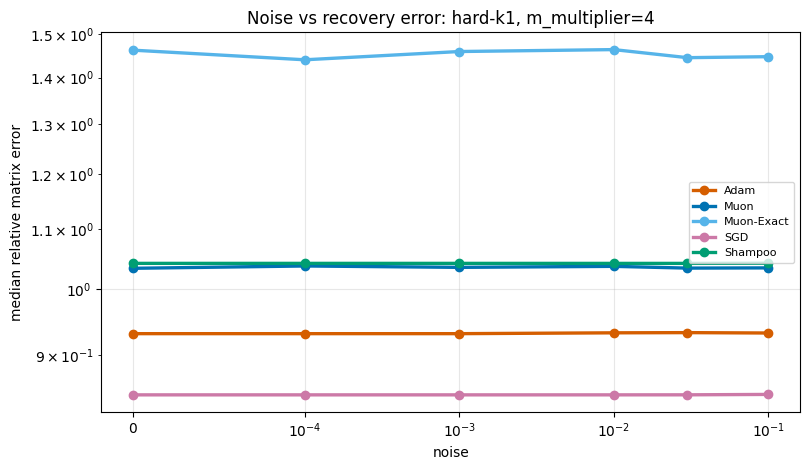

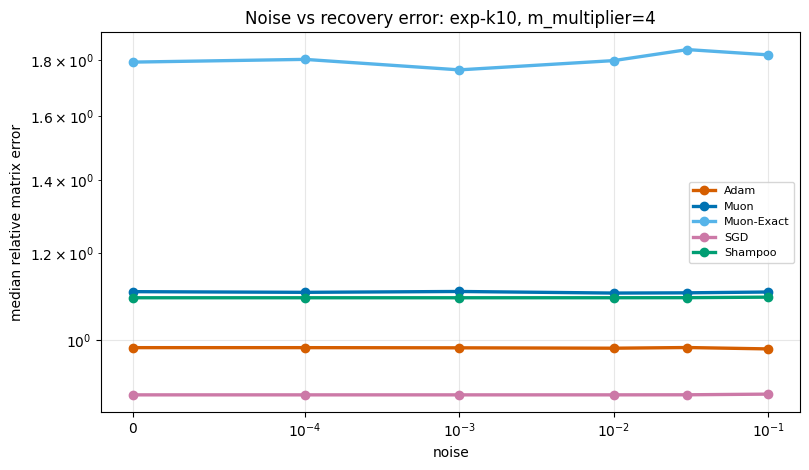

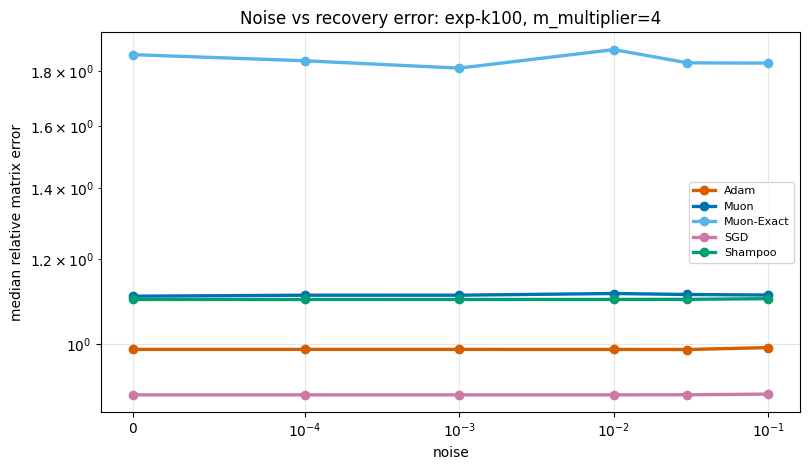

In [6]:
for spectrum_case in ["hard-k1", "exp-k10", "exp-k100"]:
    sub = run_summary[(run_summary["spectrum_case"] == spectrum_case) & (run_summary["m_multiplier"] == 4)]
    fig, ax = plotting.plot_metric_lines(
        sub,
        x="noise",
        metric="relative_matrix_error",
        title=f"Noise vs recovery error: {spectrum_case}, m_multiplier=4",
        ylabel="median relative matrix error",
        log_x=True,
        log_y=True,
    )
    show_figure(fig)


### Noise Vs Training Loss

This plot shows the training objective $f_\sigma(X)$ from the Problem cell, so it should be read as fitting noisy observations rather than recovering $X^\star$.

This uses the same fixed spectrum, $\alpha=4$, and noise axis as the recovery-error plot, but the vertical value is seed-median final training loss $f(X_T)$. Since noisy observations create an irreducible training residual, this plot should be read as an optimization/noise-floor diagnostic, not as recovery quality.

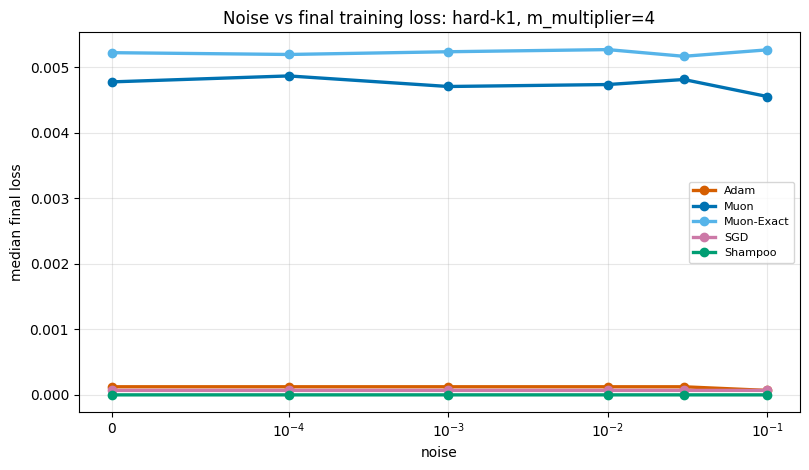

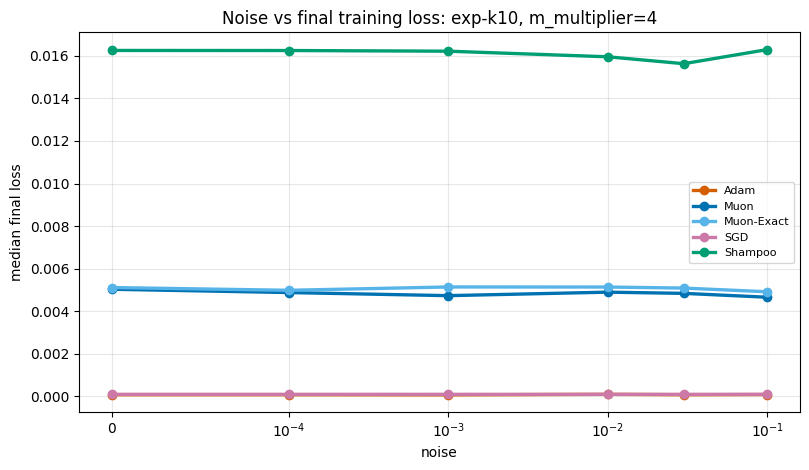

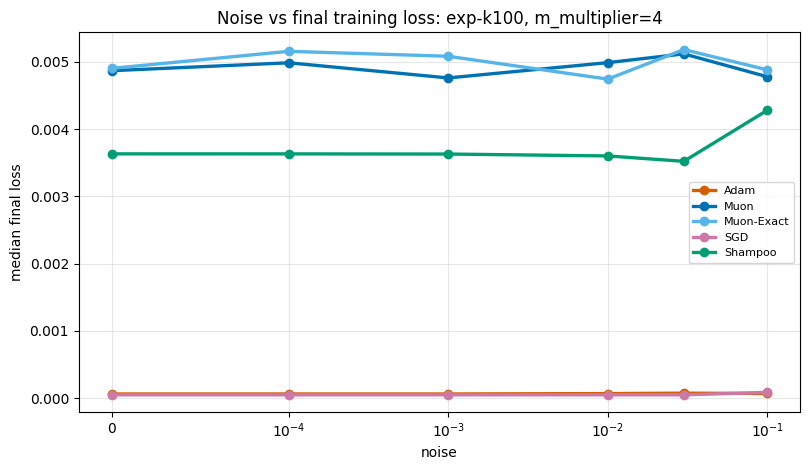

In [7]:
for spectrum_case in ["hard-k1", "exp-k10", "exp-k100"]:
    sub = run_summary[(run_summary["spectrum_case"] == spectrum_case) & (run_summary["m_multiplier"] == 4)]
    fig, ax = plotting.plot_metric_lines(
        sub,
        x="noise",
        metric="final_loss",
        title=f"Noise vs final training loss: {spectrum_case}, m_multiplier=4",
        ylabel="median final loss",
        log_x=True,
        log_y=False,
    )
    show_figure(fig)


### Noise Vs Log Training Loss

This is the same noisy objective $f_\sigma(X)$ from the Problem cell, shown on a log scale to expose how the noise floor changes across $\sigma$.

This is the same final-training-loss statistic on a logarithmic vertical axis. It keeps spectrum as the outer figure, $\sigma$ as the horizontal axis, and optimizer as color. Use it when the linear training-loss plot hides small-loss differences at low noise or order-of-magnitude differences at high noise.

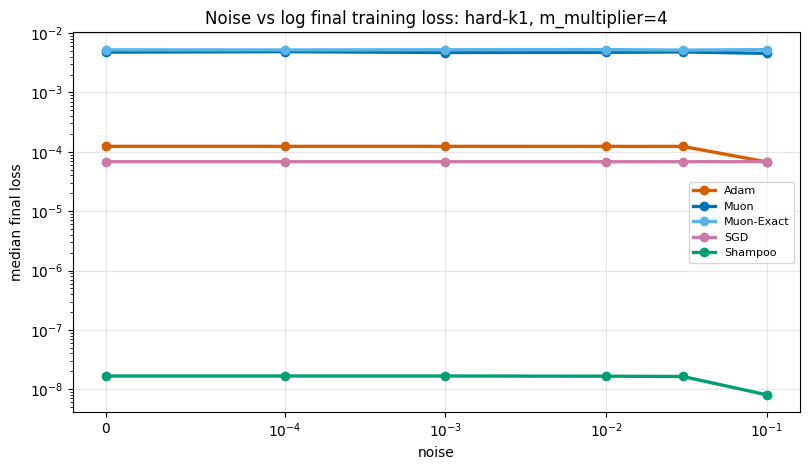

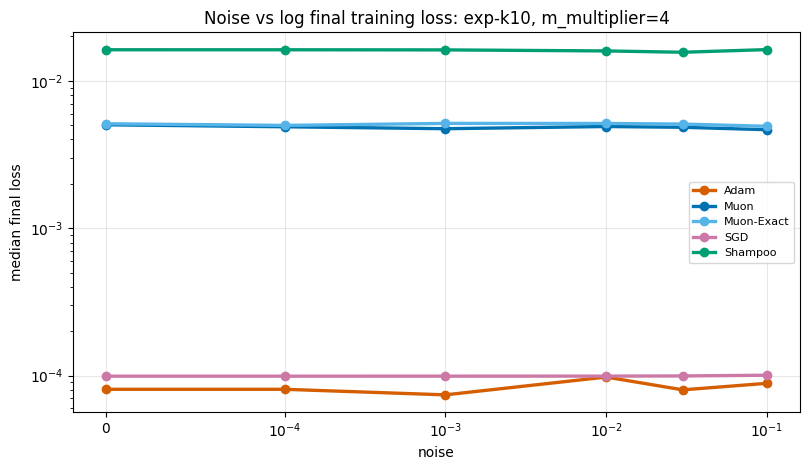

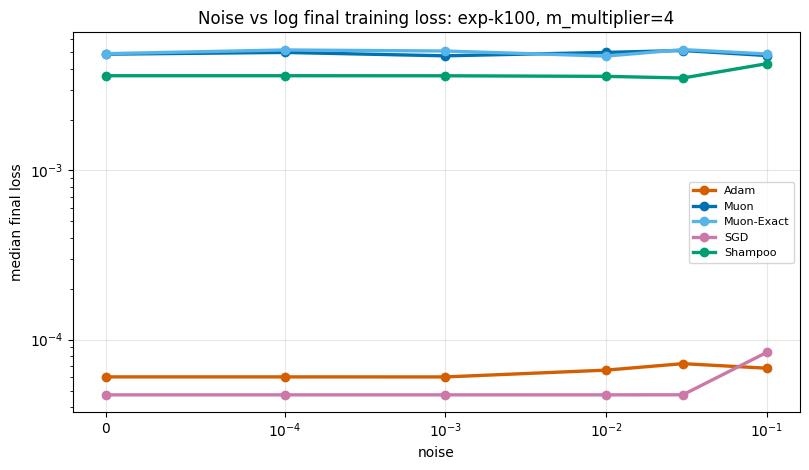

In [8]:
for spectrum_case in ["hard-k1", "exp-k10", "exp-k100"]:
    sub = run_summary[(run_summary["spectrum_case"] == spectrum_case) & (run_summary["m_multiplier"] == 4)]
    fig, ax = plotting.plot_metric_lines(
        sub,
        x="noise",
        metric="final_loss",
        title=f"Noise vs log final training loss: {spectrum_case}, m_multiplier=4",
        ylabel="median final loss",
        log_x=True,
        log_y=True,
    )
    show_figure(fig)


### Recovery-Over-Training Gap

This plot directly connects the two quantities distinguished in the Problem cell: recovery of $X^\star$ versus minimization of the noisy training objective.

This plot compares what the optimizer fits to what we care about. The horizontal axis is noise scale $\sigma$, color is optimizer, and the vertical value is $\log_{10}(e(\widehat X))-\log_{10}(f(X_T))$, with both quantities summarized by seed medians. Large positive values mean the training loss looks much better than the recovery error, which is a warning sign for noisy or ill-conditioned sensing.

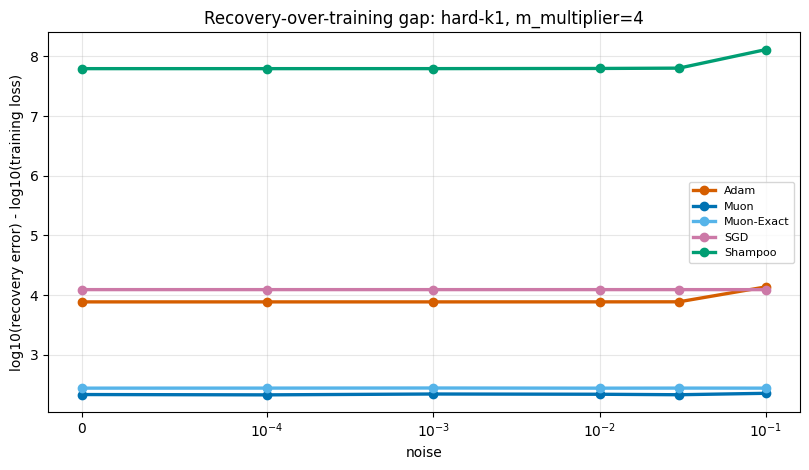

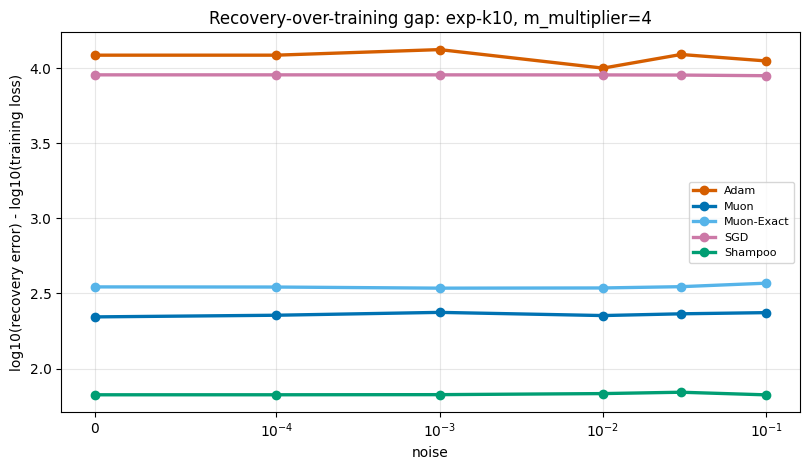

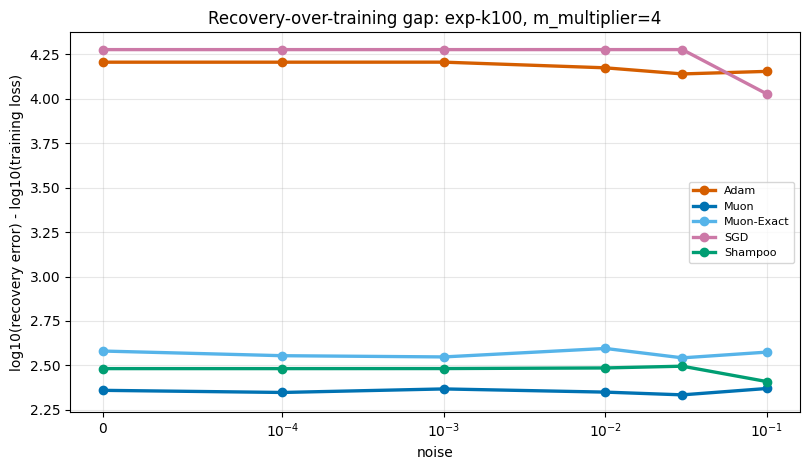

In [9]:
for spectrum_case in ["hard-k1", "exp-k10", "exp-k100"]:
    sub = run_summary[(run_summary["spectrum_case"] == spectrum_case) & (run_summary["m_multiplier"] == 4)]
    fig, ax = plotting.plot_metric_lines(
        sub,
        x="noise",
        metric="recovery_loss_gap",
        title=f"Recovery-over-training gap: {spectrum_case}, m_multiplier=4",
        ylabel="log10(recovery error) - log10(training loss)",
        log_x=True,
    )
    show_figure(fig)


### Muon Vs Adam Noise Gap

The Problem cell asks about optimizer robustness under increasing $\sigma$; this plot reduces that comparison to Muon versus Adam recovery error.

Each figure fixes the spectrum and $\alpha=4$ and compares only Muon against Adam across noise levels. The horizontal axis is $\sigma$ and the vertical value is $\log_{10}(e_{\mathrm{Muon}})-\log_{10}(e_{\mathrm{Adam}})$ after taking seed-median recovery errors. The horizontal zero line is equality; negative values favor Muon and positive values favor Adam.

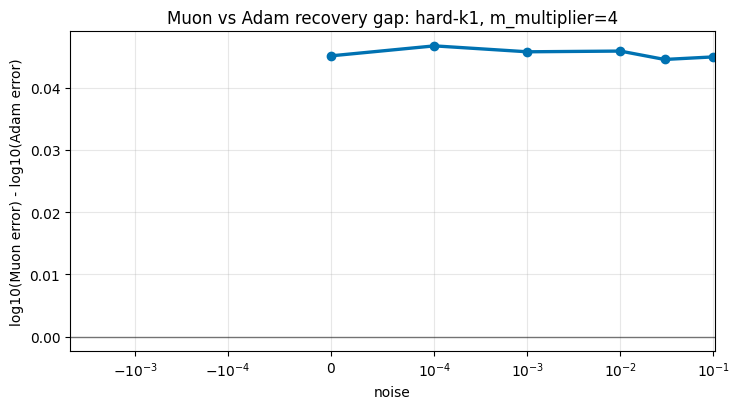

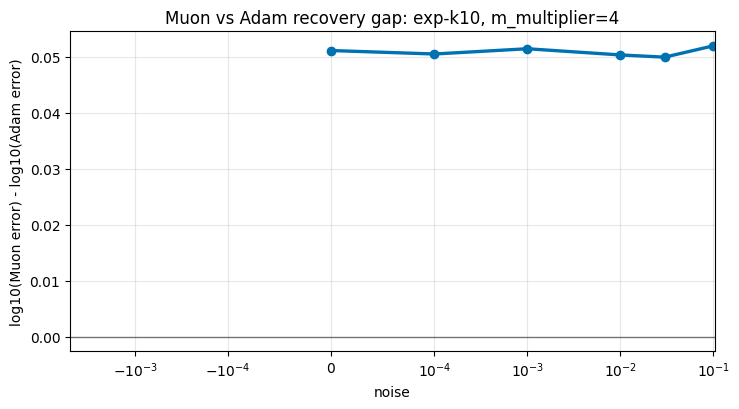

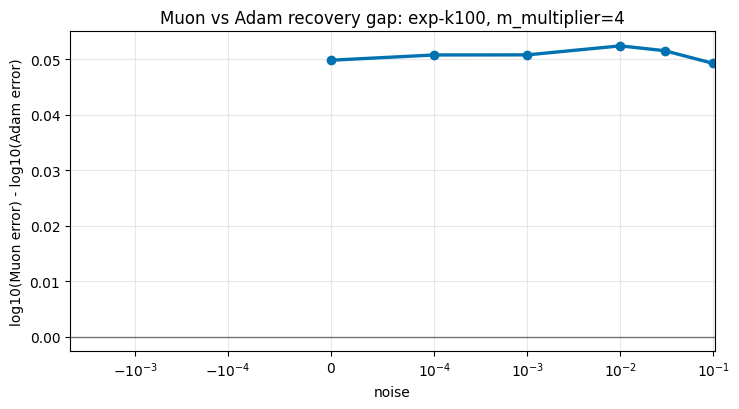

In [10]:
for spectrum_case in ["hard-k1", "exp-k10", "exp-k100"]:
    sub = run_summary[(run_summary["spectrum_case"] == spectrum_case) & (run_summary["m_multiplier"] == 4)]
    grouped = sub.groupby(["noise", "algo"], as_index=False, observed=True)["relative_matrix_error"].median()
    pivot = grouped.pivot(index="noise", columns="algo", values="relative_matrix_error")
    gap = np.log10(pivot["Muon"].clip(lower=1e-300)) - np.log10(pivot["Adam"].clip(lower=1e-300))
    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    ax.plot(gap.index, gap.values, marker="o", color=plotting.algorithm_color("Muon"), linewidth=2.4)
    ax.axhline(0, color="black", linewidth=1, alpha=0.5)
    ax.set_xscale("symlog", linthresh=1e-4)
    ax.set_title(f"Muon vs Adam recovery gap: {spectrum_case}, m_multiplier=4")
    ax.set_xlabel("noise")
    ax.set_ylabel("log10(Muon error) - log10(Adam error)")
    ax.grid(alpha=0.3)
    fig.tight_layout()
    show_figure(fig)


### Representative Loss Curves

These selected regimes instantiate the Problem cell’s clean-versus-noisy contrast and show how the optimization path changes.

The two panels compare a clean hard instance with a noisy hard instance. In each panel, the horizontal axis is step $t$, the vertical axis is median training loss over seeds, and color is optimizer. This plot shows how noise changes the shape and floor of the optimization trajectory at a fixed spectrum and sample complexity.

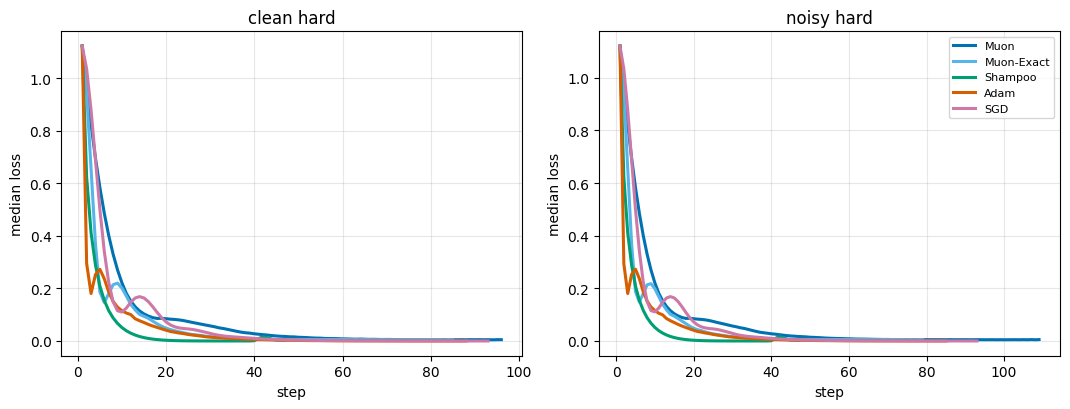

In [11]:
REPRESENTATIVE = [("clean hard", "exp-k100", 4, 0.0), ("noisy hard", "exp-k100", 4, 3e-2)]
fig, axes = plt.subplots(1, len(REPRESENTATIVE), figsize=(5.4 * len(REPRESENTATIVE), 4.2), sharey=False)
for ax, (label, spectrum_case, m_multiplier, noise) in zip(axes, REPRESENTATIVE):
    sub = runs[(runs["spectrum_case"] == spectrum_case) & (runs["m_multiplier"] == m_multiplier) & (runs["noise"] == noise)]
    for algo in ALGOS:
        curve = sub[sub["algo"] == algo].groupby("step", as_index=False)["loss"].median()
        ax.plot(curve["step"], curve["loss"], color=plotting.algorithm_color(algo), linewidth=2.2, label=algo)
    ax.set_title(label)
    ax.set_xlabel("step")
    ax.set_ylabel("median loss")
    ax.grid(alpha=0.3)
axes[-1].legend(fontsize=8)
fig.tight_layout()
show_figure(fig)


### Representative Log-Loss Curves

This repeats the same Problem-cell contrast with a log axis so noise-floor and late-time differences are easier to see.

This repeats the clean/noisy comparison with a logarithmic loss axis. The encoded dimensions are the same as above: panel is regime, horizontal axis is step, color is optimizer. Use the log view to see whether methods differ mainly in early descent, late-time floor, or both.

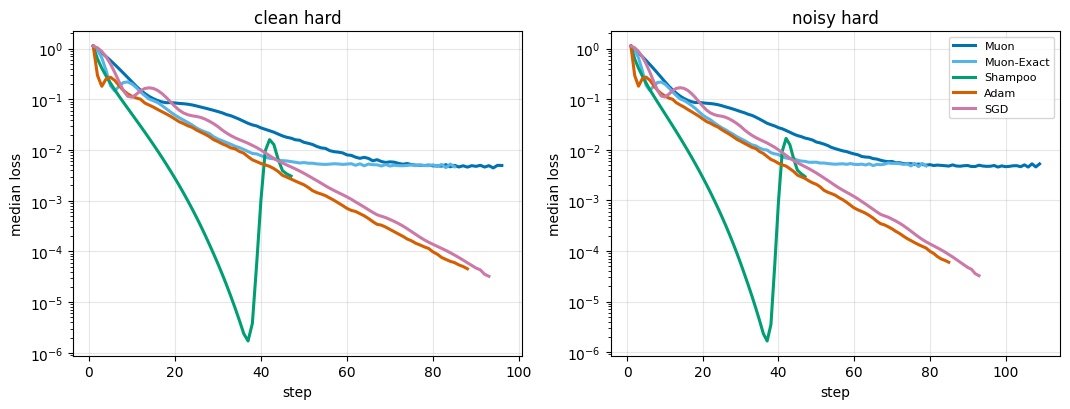

In [12]:
fig, axes = plt.subplots(1, len(REPRESENTATIVE), figsize=(5.4 * len(REPRESENTATIVE), 4.2), sharey=False)
for ax, (label, spectrum_case, m_multiplier, noise) in zip(axes, REPRESENTATIVE):
    sub = runs[(runs["spectrum_case"] == spectrum_case) & (runs["m_multiplier"] == m_multiplier) & (runs["noise"] == noise)]
    for algo in ALGOS:
        curve = sub[sub["algo"] == algo].groupby("step", as_index=False)["loss"].median()
        ax.plot(curve["step"], curve["loss"], color=plotting.algorithm_color(algo), linewidth=2.2, label=algo)
    ax.set_title(label)
    ax.set_xlabel("step")
    ax.set_ylabel("median loss")
    ax.set_yscale("log")
    ax.grid(alpha=0.3)
axes[-1].legend(fontsize=8)
fig.tight_layout()
show_figure(fig)


### Main Table


In [13]:
noise_table = run_summary.groupby(["spectrum_case", "noise", "algo"], as_index=False, observed=True).agg(
    median_recovery=("relative_matrix_error", "median"),
    median_loss=("final_loss", "median"),
    median_fresh_mse=("fresh_noiseless_mse", "median"),
    divergence_rate=("diverged", "mean"),
)
best_recovery = noise_table.sort_values("median_recovery").groupby(["spectrum_case", "noise"], as_index=False, observed=True).first()
IPython.display.display(best_recovery)


,spectrum_case,noise,algo,median_recovery,median_loss,median_fresh_mse,divergence_rate
0,exp-k10,0.0000,SGD,0.891287,0.000108,0.790837,0.0
1,exp-k10,0.0001,SGD,0.891287,0.000108,0.790842,0.0
2,exp-k10,0.0010,SGD,0.891287,0.000108,0.790881,0.0
3,exp-k10,0.0100,SGD,0.891301,0.000108,0.791303,0.0
4,exp-k10,0.0300,SGD,0.891413,0.000108,0.792394,0.0
5,exp-k10,0.1000,SGD,0.892672,0.000106,0.794803,0.0
6,exp-k100,0.0000,SGD,0.896211,0.000099,0.743412,0.0
7,exp-k100,0.0001,SGD,0.896211,0.000099,0.743416,0.0
8,exp-k100,0.0010,SGD,0.896211,0.000099,0.743454,0.0
9,exp-k100,0.0100,SGD,0.896226,0.000099,0.743860,0.0


### Reading The Result

Muon is robust only if recovery error remains competitive as noise grows. If training loss falls while recovery error or fresh noiseless error worsens, the optimizer is fitting the noisy observations rather than recovering `X_star`.
